In [2]:
print("Azure Machine Learning compute is working!")

Azure Machine Learning compute is working!


In [3]:
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential

ml_client = MLClient.from_config(
    credential=DefaultAzureCredential()
)

data_asset = ml_client.data.get(
    name="divvy_tripdata_raw",
    version="1"
)

print("Data asset found:")
print(data_asset.name)
print(data_asset.path)

Found the config file in: /config.json


Data asset found:
divvy_tripdata_raw
azureml://subscriptions/722f7699-2db3-4ee4-9db5-f740a1a6972c/resourcegroups/rg-azure-ai-learning/workspaces/mlw-divvy-ai-learning/datastores/divvy_blob_datastore/paths/raw-data/202107-divvy-tripdata.csv


In [4]:
import pandas as pd

df = pd.read_csv(data_asset.path)

print("Dataset loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

Overriding of current MeterProvider is not allowed
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/mlflow/__init__.py:41: UserWarning: Versions of mlflow (3.16.0) and child packages mlflow-skinny (3.15.0) are different. This may lead to unexpected behavior. Please install the same version of all MLflow packages.
  mlflow.mismatch._check_version_mismatch()
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as noteboo

Dataset loaded successfully!
Rows: 822410
Columns: 13


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,0A1B623926EF4E16,docked_bike,2021-07-02 14:44:36,2021-07-02 15:19:58,Michigan Ave & Washington St,13001,Halsted St & North Branch St,KA1504000117,41.883984,-87.624684,41.899368,-87.648480,casual
1,B2D5583A5A5E76EE,classic_bike,2021-07-07 16:57:42,2021-07-07 17:16:09,California Ave & Cortez St,17660,Wood St & Hubbard St,13432,41.900363,-87.696704,41.889899,-87.671473,casual
2,6F264597DDBF427A,classic_bike,2021-07-25 11:30:55,2021-07-25 11:48:45,Wabash Ave & 16th St,SL-012,Rush St & Hubbard St,KA1503000044,41.860384,-87.625813,41.890173,-87.626185,member
3,379B58EAB20E8AA5,classic_bike,2021-07-08 22:08:30,2021-07-08 22:23:32,California Ave & Cortez St,17660,Carpenter St & Huron St,13196,41.900363,-87.696704,41.894556,-87.653449,member
4,6615C1E4EB08E8FB,electric_bike,2021-07-28 16:08:06,2021-07-28 16:27:09,California Ave & Cortez St,17660,Elizabeth (May) St & Fulton St,13197,41.900350,-87.696682,41.886593,-87.658387,casual


In [5]:
# Inspect dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 822410 entries, 0 to 822409
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             822410 non-null  object 
 1   rideable_type       822410 non-null  object 
 2   started_at          822410 non-null  object 
 3   ended_at            822410 non-null  object 
 4   start_station_name  735147 non-null  object 
 5   start_station_id    735148 non-null  object 
 6   end_station_name    729252 non-null  object 
 7   end_station_id      729252 non-null  object 
 8   start_lat           822410 non-null  float64
 9   start_lng           822410 non-null  float64
 10  end_lat             821679 non-null  float64
 11  end_lng             821679 non-null  float64
 12  member_casual       822410 non-null  object 
dtypes: float64(4), object(9)
memory usage: 81.6+ MB


In [6]:
# Check missing values
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().sum() / len(df) * 100).round(2)
})

missing

,missing_count,missing_percent
ride_id,0,0.00
rideable_type,0,0.00
started_at,0,0.00
ended_at,0,0.00
start_station_name,87263,10.61
start_station_id,87262,10.61
end_station_name,93158,11.33
end_station_id,93158,11.33
start_lat,0,0.00
start_lng,0,0.00


In [7]:
# Check for duplicate records and duplicate ride IDs

print("Duplicate rows:", df.duplicated().sum())
print("Duplicate ride IDs:", df["ride_id"].duplicated().sum())
print("Unique ride IDs:", df["ride_id"].nunique())

Duplicate rows: 0
Duplicate ride IDs: 0
Unique ride IDs: 822410


In [8]:
# Convert timestamp columns from text to datetime

df["started_at"] = pd.to_datetime(df["started_at"])
df["ended_at"] = pd.to_datetime(df["ended_at"])

print(df[["started_at", "ended_at"]].dtypes)

started_at    datetime64[ns]
ended_at      datetime64[ns]
dtype: object


In [9]:
# Create trip duration in minutes

df["trip_duration_minutes"] = (
    df["ended_at"] - df["started_at"]
).dt.total_seconds() / 60

df["trip_duration_minutes"].describe()

count    822410.000000
mean         24.210642
std         214.191034
min          -0.200000
25%           7.583333
50%          13.350000
75%          23.733333
max       49107.150000
Name: trip_duration_minutes, dtype: float64

In [10]:
invalid_duration = df[df["trip_duration_minutes"] <= 0]

print("Zero/negative duration trips:", len(invalid_duration))

Zero/negative duration trips: 82


In [11]:
df = df[df["trip_duration_minutes"] > 0].copy()

print("Remaining trips:", len(df))

Remaining trips: 822328


In [12]:
# Check unusually long trips

print("Trips over 24 hours:",
      (df["trip_duration_minutes"] > 1440).sum())

print("Trips over 12 hours:",
      (df["trip_duration_minutes"] > 720).sum())

Trips over 24 hours: 611
Trips over 12 hours: 1028


In [13]:
df.nlargest(
    10,
    "trip_duration_minutes"
)[["ride_id", "rideable_type", "started_at", "ended_at",
   "trip_duration_minutes", "member_casual"]]

,ride_id,rideable_type,started_at,ended_at,trip_duration_minutes,member_casual
640346,99415B003B7E7EEE,docked_bike,2021-07-08 19:29:49,2021-08-11 21:56:58,49107.150000,casual
16034,89F33397EABB55E7,docked_bike,2021-07-08 15:13:08,2021-08-06 13:18:39,41645.516667,casual
331390,D4E35EE211346690,docked_bike,2021-07-10 15:59:21,2021-08-07 22:43:57,40724.600000,casual
433794,66F0486D4849C1B9,docked_bike,2021-07-03 18:39:43,2021-07-31 19:00:58,40341.250000,casual
105109,C4D95269E133379D,docked_bike,2021-07-08 19:26:21,2021-08-05 07:13:32,39587.183333,casual
114355,94E199ACBBC27DD7,docked_bike,2021-07-09 17:59:03,2021-08-05 14:44:19,38685.266667,casual
207590,26765E73FFA6E9D9,docked_bike,2021-07-18 21:30:17,2021-08-11 08:37:45,33787.466667,casual
296149,60A5341F2DE39ACD,docked_bike,2021-07-03 21:38:05,2021-07-26 12:50:41,32592.600000,casual
203427,8ECF742AF6D09DA1,docked_bike,2021-07-10 04:31:05,2021-08-01 11:09:56,32078.850000,casual
335485,50248CAA56D6D02A,docked_bike,2021-07-03 21:17:50,2021-07-25 19:02:51,31545.016667,casual


In [14]:
# Remove trips longer than 24 hours

df = df[df["trip_duration_minutes"] <= 1440].copy()

print("Remaining trips:", len(df))
print("Maximum duration:", df["trip_duration_minutes"].max())

Remaining trips: 821717
Maximum duration: 1425.0


In [15]:
# Review cleaned trip duration statistics

df["trip_duration_minutes"].describe()

count    821717.000000
mean         21.291190
std          36.300184
min           0.016667
25%           7.583333
50%          13.333333
75%          23.700000
max        1425.000000
Name: trip_duration_minutes, dtype: float64

In [16]:
# Check missing station names by bike type

df[df["start_station_name"].isna()]["rideable_type"].value_counts()

electric_bike    87262
Name: rideable_type, dtype: int64

In [17]:
# Check rider membership categories

print(df["member_casual"].value_counts())
print("\nUnique categories:", df["member_casual"].unique())

casual    441446
member    380271
Name: member_casual, dtype: int64

Unique categories: ['casual' 'member']


In [18]:
# Check bike type categories

print(df["rideable_type"].value_counts())
print("\nUnique bike types:", df["rideable_type"].unique())

classic_bike     506442
electric_bike    257763
docked_bike       57512
Name: rideable_type, dtype: int64

Unique bike types: ['docked_bike' 'classic_bike' 'electric_bike']


In [19]:
# Compare trip duration by rider type

rider_duration = df.groupby("member_casual")["trip_duration_minutes"].agg(
    ["count", "mean", "median"]
).round(2)

rider_duration

,count,mean,median
member_casual,,,
casual,441446,27.52,16.68
member,380271,14.06,10.43


In [20]:
# Create day-of-week feature

df["day_of_week"] = df["started_at"].dt.day_name()

df["day_of_week"].value_counts()

Saturday     162616
Friday       136079
Thursday     121193
Sunday       109369
Wednesday    100023
Tuesday       97722
Monday        94715
Name: day_of_week, dtype: int64

In [21]:
# Compare member vs casual trips by day

daily_rider = pd.crosstab(
    df["day_of_week"],
    df["member_casual"]
)

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

daily_rider = daily_rider.reindex(day_order)

daily_rider

member_casual,casual,member
day_of_week,,
Monday,48226,46489
Tuesday,45353,52369
Wednesday,46490,53533
Thursday,56772,64421
Friday,71875,64204
Saturday,103098,59518
Sunday,69632,39737


In [22]:
# Create trip start-hour feature

df["start_hour"] = df["started_at"].dt.hour

hourly_rider = pd.crosstab(
    df["start_hour"],
    df["member_casual"]
)

hourly_rider

member_casual,casual,member
start_hour,,
0,9761,4665
1,7554,3360
2,5447,2075
3,2963,1071
4,1765,1154
5,2105,3620
6,4335,10207
7,7245,17651
8,9998,20119


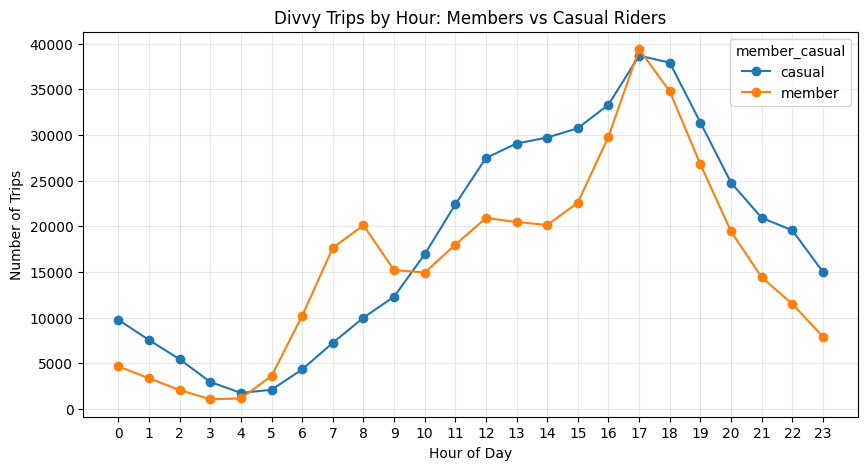

In [23]:
# Visualize hourly riding patterns

import matplotlib.pyplot as plt

hourly_rider.plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Divvy Trips by Hour: Members vs Casual Riders")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.show()

In [24]:
# Compare bike preferences by rider type

bike_rider = pd.crosstab(
    df["rideable_type"],
    df["member_casual"]
)

bike_rider

member_casual,casual,member
rideable_type,,
classic_bike,241087,265355
docked_bike,57512,0
electric_bike,142847,114916


In [25]:
# Bike type percentage within each rider group

bike_percent = pd.crosstab(
    df["rideable_type"],
    df["member_casual"],
    normalize="columns"
) * 100

bike_percent.round(2)

member_casual,casual,member
rideable_type,,
classic_bike,54.61,69.78
docked_bike,13.03,0.00
electric_bike,32.36,30.22


In [26]:
# Top 10 starting stations

top_start_stations = (
    df["start_station_name"]
    .value_counts()
    .head(10)
)

top_start_stations

Streeter Dr & Grand Ave       16991
Michigan Ave & Oak St          8405
Millennium Park                7630
Wells St & Concord Ln          6938
Theater on the Lake            6919
Lake Shore Dr & North Blvd     6380
Clark St & Elm St              6092
Wells St & Elm St              5798
Clark St & Lincoln Ave         5656
Clark St & Armitage Ave        5444
Name: start_station_name, dtype: int64

In [27]:
# Top starting stations by rider type

top_stations_by_rider = (
    df.groupby("member_casual")["start_station_name"]
      .value_counts()
      .groupby(level=0)
      .head(10)
)

top_stations_by_rider

member_casual  start_station_name        
casual         Streeter Dr & Grand Ave       14271
               Millennium Park                6326
               Michigan Ave & Oak St          6041
               Theater on the Lake            4435
               Shedd Aquarium                 4356
               Lake Shore Dr & North Blvd     4353
               Lake Shore Dr & Monroe St      4305
               Wells St & Concord Ln          3638
               Clark St & Lincoln Ave         3280
               Indiana Ave & Roosevelt Rd     3156
member         Wells St & Concord Ln          3300
               Clark St & Elm St              3151
               Wells St & Elm St              2840
               Kingsbury St & Kinzie St       2755
               Streeter Dr & Grand Ave        2720
               Theater on the Lake            2484
               Clark St & Lincoln Ave         2376
               Michigan Ave & Oak St          2364
               Clark St & Armitage Ave  

In [28]:
# Create weekday/weekend feature

df["day_type"] = df["day_of_week"].apply(
    lambda x: "Weekend" if x in ["Saturday", "Sunday"] else "Weekday"
)

day_type_summary = pd.crosstab(
    df["day_type"],
    df["member_casual"]
)

day_type_summary

member_casual,casual,member
day_type,,
Weekday,268716,281016
Weekend,172730,99255


In [29]:
# Convert weekday/weekend counts to percentages

day_type_percent = (
    day_type_summary
    / day_type_summary.sum(axis=0)
    * 100
).round(2)

day_type_percent

member_casual,casual,member
day_type,,
Weekday,60.87,73.9
Weekend,39.13,26.1


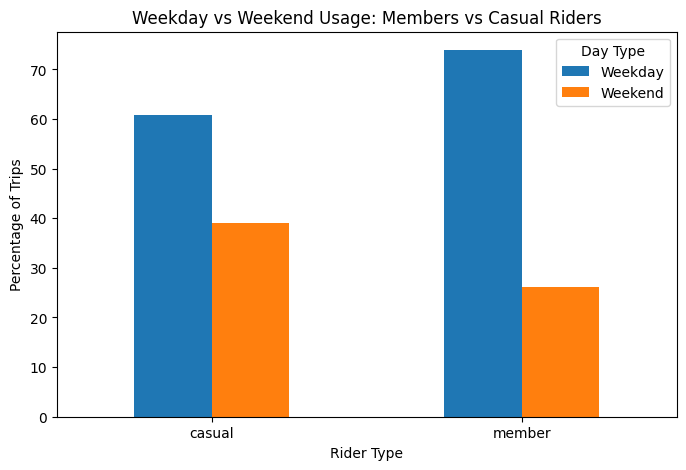

In [30]:
# Visualize weekday vs weekend riding patterns

day_type_percent.T.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Weekday vs Weekend Usage: Members vs Casual Riders")
plt.xlabel("Rider Type")
plt.ylabel("Percentage of Trips")
plt.xticks(rotation=0)
plt.legend(title="Day Type")
plt.show()

In [31]:
# Average trip duration by rider type and day type

duration_daytype = df.groupby(
    ["member_casual", "day_type"]
)["trip_duration_minutes"].mean().unstack()

duration_daytype.round(2)

day_type,Weekday,Weekend
member_casual,,
casual,25.84,30.13
member,13.47,15.72


In [32]:
# Top start stations by day type

top_stations_daytype = (
    df.groupby(["day_type", "start_station_name"])
      .size()
      .groupby(level=0, group_keys=False)
      .nlargest(10)
)

top_stations_daytype

day_type  start_station_name        
Weekday   Streeter Dr & Grand Ave       9490
          Michigan Ave & Oak St         4915
          Millennium Park               4628
          Wells St & Concord Ln         4469
          Clark St & Elm St             4095
          Wells St & Elm St             3898
          Theater on the Lake           3888
          Lake Shore Dr & North Blvd    3596
          Wabash Ave & Grand Ave        3498
          Kingsbury St & Kinzie St      3403
Weekend   Streeter Dr & Grand Ave       7501
          Michigan Ave & Oak St         3490
          Theater on the Lake           3031
          Millennium Park               3002
          Lake Shore Dr & North Blvd    2784
          Wells St & Concord Ln         2469
          Clark St & Lincoln Ave        2394
          Lake Shore Dr & Monroe St     2343
          Clark St & Armitage Ave       2137
          Clark St & Elm St             1997
dtype: int64

In [33]:
# Prepare spatial sample for mapping

map_data = df[
    ["start_lat", "start_lng", "member_casual"]
].dropna().sample(10000, random_state=42)

print("Points prepared for mapping:", len(map_data))
map_data.head()

Points prepared for mapping: 10000


,start_lat,start_lng,member_casual
597720,41.850000,-87.690000,member
628581,41.894138,-87.629104,casual
482509,41.896910,-87.621743,member
309862,41.870769,-87.625734,member
455188,41.834900,-87.617930,casual


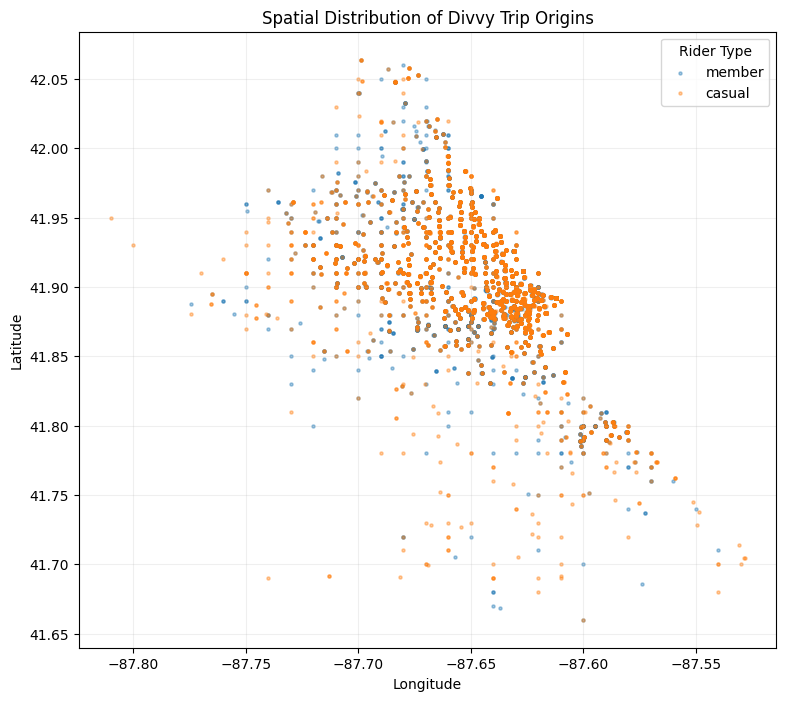

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 8))

for rider in ["member", "casual"]:
    subset = map_data[map_data["member_casual"] == rider]

    plt.scatter(
        subset["start_lng"],
        subset["start_lat"],
        s=5,
        alpha=0.4,
        label=rider
    )

plt.title("Spatial Distribution of Divvy Trip Origins")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Rider Type")
plt.grid(alpha=0.2)
plt.show()

In [35]:
import folium

print("Folium version:", folium.__version__)

ModuleNotFoundError: No module named 'folium'

In [36]:
%pip install folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [folium]
Note: you may need to restart the kernel to use updated packages.


In [37]:
import folium

print("Folium version:", folium.__version__)

Folium version: 0.20.0


In [38]:
# Create interactive Divvy trip origin map

divvy_map = folium.Map(
    location=[41.88, -87.63],
    zoom_start=11
)

for _, row in map_data.iterrows():
    folium.CircleMarker(
        location=[row["start_lat"], row["start_lng"]],
        radius=2,
        fill=True,
        fill_opacity=0.4,
        weight=0
    ).add_to(divvy_map)

divvy_map

In [39]:
# Check geographic coordinate ranges

print("Latitude range:")
print(df["start_lat"].min(), "to", df["start_lat"].max())

print("\nLongitude range:")
print(df["start_lng"].min(), "to", df["start_lng"].max())

Latitude range:
41.64850076266409 to 42.07

Longitude range:
-87.84 to -87.52


In [40]:
# Create Chicago-focused interactive map

divvy_map = folium.Map(
    location=[41.88, -87.65],
    zoom_start=11,
    tiles="OpenStreetMap"
)

for _, row in map_data.iterrows():
    folium.CircleMarker(
        location=[row["start_lat"], row["start_lng"]],
        radius=2,
        fill=True,
        fill_opacity=0.4,
        weight=0
    ).add_to(divvy_map)

divvy_map

In [41]:
# Interactive map by rider type

rider_map = folium.Map(
    location=[41.88, -87.65],
    zoom_start=11
)

for _, row in map_data.iterrows():

    color = "blue" if row["member_casual"] == "member" else "orange"

    folium.CircleMarker(
        location=[row["start_lat"], row["start_lng"]],
        radius=2,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.5,
        weight=0
    ).add_to(rider_map)

rider_map

In [42]:
# Geographic center of trip origins by rider type

rider_centers = df.groupby("member_casual")[
    ["start_lat", "start_lng"]
].mean()

rider_centers

,start_lat,start_lng
member_casual,,
casual,41.902650,-87.643894
member,41.904668,-87.647447


In [43]:
# Final project KPI summary

summary = pd.DataFrame({
    "Metric": [
        "Cleaned Trips",
        "Casual Trips",
        "Member Trips",
        "Average Casual Duration (min)",
        "Average Member Duration (min)",
        "Weekend Casual Share (%)",
        "Weekend Member Share (%)"
    ],
    "Value": [
        len(df),
        (df["member_casual"] == "casual").sum(),
        (df["member_casual"] == "member").sum(),
        df[df["member_casual"] == "casual"]["trip_duration_minutes"].mean(),
        df[df["member_casual"] == "member"]["trip_duration_minutes"].mean(),
        day_type_percent.loc["Weekend", "casual"],
        day_type_percent.loc["Weekend", "member"]
    ]
})

summary.round(2)

,Metric,Value
0,Cleaned Trips,821717.00
1,Casual Trips,441446.00
2,Member Trips,380271.00
3,Average Casual Duration (min),27.52
4,Average Member Duration (min),14.06
5,Weekend Casual Share (%),39.13
6,Weekend Member Share (%),26.10


In [44]:
# Save cleaned dataset

df.to_csv("divvy_trips_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Cleaned dataset saved successfully!
Rows: 821717
Columns: 17


In [45]:
# Save interactive map as HTML

rider_map.save("divvy_rider_map.html")

print("Interactive map saved successfully!")

Interactive map saved successfully!


In [46]:
# Save project KPI summary

summary.round(2).to_csv("divvy_analysis_summary.csv", index=False)

print("KPI summary saved successfully!")

KPI summary saved successfully!
